<a href="https://colab.research.google.com/github/palahb/no2-prediction/blob/main/progress_report_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatiotemporal NO2 Prediction using A3T-GCN
## Progress Report 1 — Data Analysis & Graph Construction

**Course:** CMP712 - Machine Learning  
**Student:** Halil Burak Pala  
**Institution:** Hacettepe University, Department of Computer Engineering  
**Reference Paper:** Iskandaryan et al., *Graph Neural Network for Air Quality Prediction: A Case Study in Madrid*, IEEE Access, 2023

---

### Scope of This Report
This notebook covers the first phase of the implementation pipeline:
1. Environment setup & library verification
2. Data loading & validation
3. Exploratory Data Analysis (EDA)
4. Graph construction from station distance data
5. Feature engineering (Z-score normalization, sliding window)

> **Note:** Model training (GRU, LSTM, T-GCN, A3T-GCN) is deferred to Progress Report 2.

## 1. Environment Setup

First, we verify the installed PyTorch version and CUDA availability. This is crucial for ensuring compatibility with GPU-accelerated operations, especially for graph neural network libraries that often rely on specific PyTorch and CUDA versions.

In [26]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


Next, we install the necessary libraries for this project. This includes `torch-geometric` (PyG) for graph neural networks, along with its dependencies (`pyg_lib`, `torch_scatter`, `torch_sparse`, `torch_cluster`, `torch_spline_conv`), and `torch-geometric-temporal` for spatiotemporal graph neural networks. The `-f` flag ensures compatibility with the specific CUDA version.

In [27]:
# Install required libraries
!pip install torch-geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q
!pip install torch-geometric-temporal -q

Finally, we import standard data science and machine learning libraries such as `pandas`, `numpy`, `matplotlib`, and `seaborn`. We also import `StandardScaler` from `sklearn.preprocessing` for data normalization. Random seeds are set for reproducibility, the computing device (CPU/GPU) is detected, and `matplotlib` plotting styles are configured for consistent visualization.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import torch
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All libraries loaded successfully.')

Device: cuda
GPU: Tesla T4
All libraries loaded successfully.


## 2. Data Loading

In [29]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
!ls "/content/drive/MyDrive/cmp712_2026_project"

progress_report_1.ipynb  raw_dataset


In [31]:
!ls "/content/drive/MyDrive/cmp712_2026_project/raw_dataset"

distanceNodes.txt  Mad_Station_2019.csv  Mad_Station_2022.csv


In [32]:
TRAIN_PATH = '/content/drive/MyDrive/cmp712_2026_project/raw_dataset/Mad_Station_2019.csv'
TEST_PATH  = '/content/drive/MyDrive/cmp712_2026_project/raw_dataset/Mad_Station_2022.csv'
DIST_PATH  = '/content/drive/MyDrive/cmp712_2026_project/raw_dataset/distanceNodes.txt'

# Dataset constants (from the reference paper)
N_STATIONS  = 24
TARGET_COL  = 'NO2'
WINDOW_SIZE = 12   # 12-hour historical input window
HORIZON     = 1    # 1-hour ahead forecast (extendable to 12)

# Column definitions
# windDir: raw angle used only to produce one-hot columns — NOT a model feature
ONE_HOT_COLS = [
    'windDir_Categ_east', 'windDir_Categ_north', 'windDir_Categ_northeast',
    'windDir_Categ_northwest', 'windDir_Categ_south', 'windDir_Categ_southeast',
    'windDir_Categ_southwest', 'windDir_Categ_west'
]
NUMERIC_COLS = [
    'NO2', 'windSpeed', 'Temp', 'Humidity', 'Pressure', 'SolarRad',
    'intensidad', 'ocupacion', 'carga', 'vmed'
]
# All model input features (18 total after dropping raw windDir)
MODEL_FEATURE_COLS = NUMERIC_COLS + ONE_HOT_COLS

# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
dist_df  = pd.read_csv(DIST_PATH, sep='\t')

# Drop raw windDir if present (already encoded)
for df in [train_df, test_df]:
    if 'windDir' in df.columns:
        df.drop(columns=['windDir'], inplace=True)

print(f'Train dataset : {train_df.shape}')
print(f'Test dataset  : {test_df.shape}')
print(f'Distance file : {dist_df.shape}')
print(f'\nFeature columns ({len(MODEL_FEATURE_COLS)}): {MODEL_FEATURE_COLS}')

Train dataset : (104256, 18)
Test dataset  : (104232, 18)
Distance file : (552, 9)

Feature columns (18): ['NO2', 'windSpeed', 'Temp', 'Humidity', 'Pressure', 'SolarRad', 'intensidad', 'ocupacion', 'carga', 'vmed', 'windDir_Categ_east', 'windDir_Categ_north', 'windDir_Categ_northeast', 'windDir_Categ_northwest', 'windDir_Categ_south', 'windDir_Categ_southeast', 'windDir_Categ_southwest', 'windDir_Categ_west']


### Dataset Overview

The dataset used in this project is sourced from the city of Madrid, Spain, and consists of two splits: a training set (January–June 2019 provided in `Mad_Station_2019.csv`) and a test set (January–June 2022 provided in `Mad_Station_2022.csv`), both covering approximately 6 months (~181 days) of hourly measurements.

**Structure:** The data contains 24 air quality monitoring stations. Each station has 4,344 hourly observations, yielding 104,256 rows per split when all stations are stacked. Each row represents one station at one hour and contains 18 features:

- **Target:** `NO2` — nitrogen dioxide concentration (µg/m³)
- **Meteorological (5):** `windSpeed`, `Temp`, `Humidity`, `Pressure`, `SolarRad`
- **Traffic (4):** `intensidad`, `ocupacion`, `carga`, `vmed`
- **Wind direction — one-hot encoded (8):** `windDir_Categ_east/north/northeast/northwest/south/southeast/southwest/west`

The raw `windDir` column (continuous angle in degrees) was used solely to produce the one-hot encoding and is excluded from model inputs.

**Temporal structure:** Each 4,344-row block per station corresponds to 4,344 consecutive hours. A sliding window of 12 hours is applied to construct input–output pairs: the model receives the past 12 hourly snapshots across all 24 stations and predicts NO2 concentration 1 hour ahead at each station, yielding 4,332 samples from the test set alone.

**Spatial structure:** The 24 stations are connected in an undirected weighted graph where edge weights are defined as w = 1/d (inverse distance in metres), computed from the provided ArcPy-generated distance file (`distanceNodes.txt`). This graph encodes the spatial proximity between stations and is the core structural input to the A3T-GCN model.

**A side note:**

Some column names are in Spanish, since the data providers are from Spain. In this context
- `carga` means "load"
- `intensidad` means "intesity"
- `ocupacion` means "occupancy"
- `vmed` means "average velocity"

In [33]:
# Verify dataset dimensions
rows_per_station_train = len(train_df) // N_STATIONS
rows_per_station_test  = len(test_df)  // N_STATIONS
print(f'Timesteps per station — Train: {rows_per_station_train} | Test: {rows_per_station_test}')
print(f'\nMissing values — Train:\n{train_df.isnull().sum()}')
print(f'\nMissing values — Test:\n{test_df.isnull().sum()}')

Timesteps per station — Train: 4344 | Test: 4343

Missing values — Train:
NO2                        0
windSpeed                  0
Temp                       0
Humidity                   0
Pressure                   0
SolarRad                   0
intensidad                 0
ocupacion                  0
carga                      0
vmed                       0
windDir_Categ_east         0
windDir_Categ_north        0
windDir_Categ_northeast    0
windDir_Categ_northwest    0
windDir_Categ_south        0
windDir_Categ_southeast    0
windDir_Categ_southwest    0
windDir_Categ_west         0
dtype: int64

Missing values — Test:
NO2                        0
windSpeed                  0
Temp                       0
Humidity                   0
Pressure                   0
SolarRad                   0
intensidad                 0
ocupacion                  0
carga                      0
vmed                       0
windDir_Categ_east         0
windDir_Categ_north        0
windDir_Categ_north

## 3. Exploratory Data Analysis (EDA)

In [34]:
# 3a. Descriptive statistics — compared with paper Table 2
print('=== Train NO2 Statistics ===')
print(train_df['NO2'].describe().round(2))
print(f'Mean: {train_df["NO2"].mean():.2f} µg/m³  (Paper 2019 reference: 36.63 µg/m³)')

print('\n=== Test NO2 Statistics ===')
print(test_df['NO2'].describe().round(2))
print(f'Mean: {test_df["NO2"].mean():.2f} µg/m³  (Paper 2022 reference: 27.96 µg/m³)')

print('\n=== All Features — Train Summary ===')
print(train_df[NUMERIC_COLS].describe().round(2))

=== Train NO2 Statistics ===
count    104256.00
mean         36.63
std          30.86
min           0.00
25%          14.00
50%          27.00
75%          52.00
max         328.00
Name: NO2, dtype: float64
Mean: 36.63 µg/m³  (Paper 2019 reference: 36.63 µg/m³)

=== Test NO2 Statistics ===
count    104232.00
mean         27.96
std          23.66
min           0.00
25%          11.00
50%          20.00
75%          38.00
max         625.00
Name: NO2, dtype: float64
Mean: 27.96 µg/m³  (Paper 2022 reference: 27.96 µg/m³)

=== All Features — Train Summary ===
             NO2  windSpeed       Temp   Humidity   Pressure   SolarRad  \
count  104256.00  104256.00  104256.00  104256.00  104256.00  104256.00   
mean       36.63       1.33      13.21      49.58     943.81     223.96   
std        30.86       1.04       7.81      20.86      17.89     302.56   
min         0.00       0.00      -3.00       0.00       0.00       0.00   
25%        14.00       0.58       7.50      33.00     940.00   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

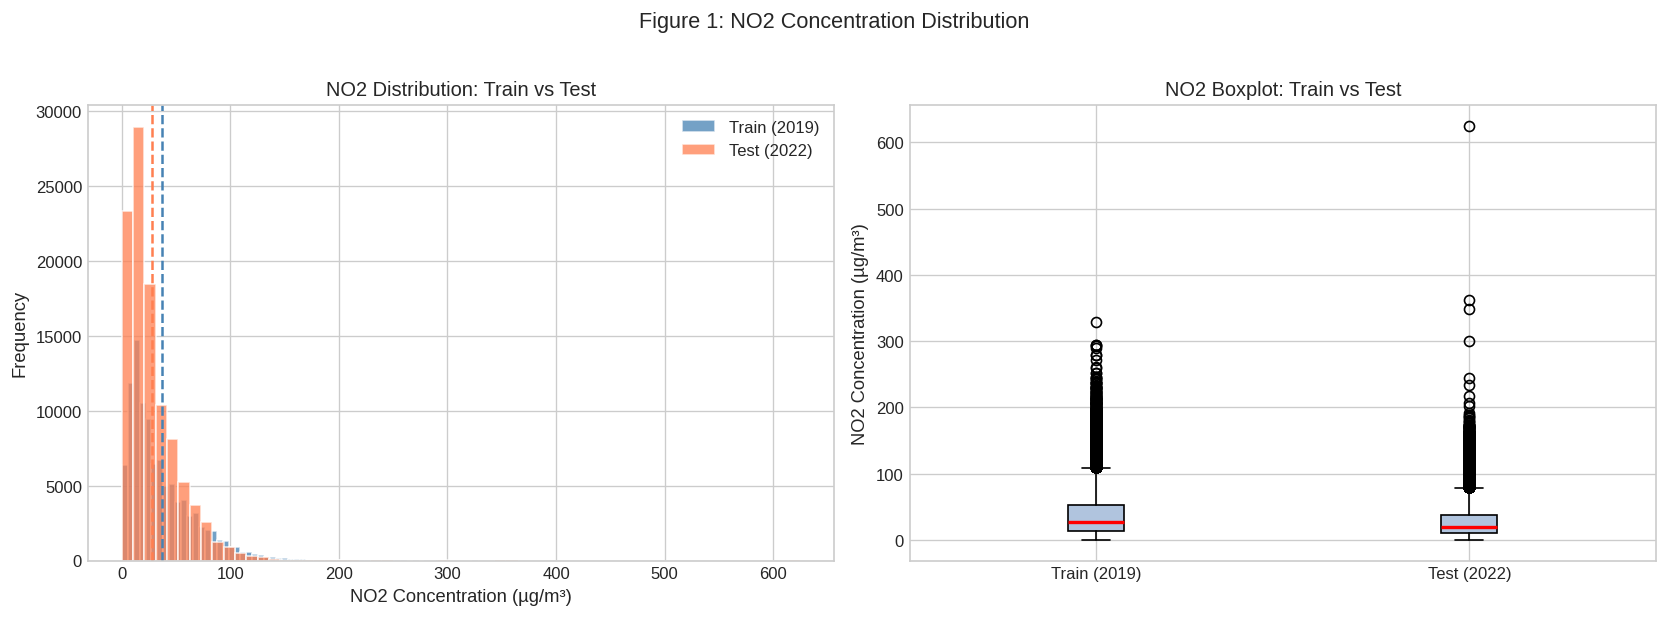

Saved: fig1_no2_distribution.png


In [35]:
# 3b. NO2 distribution: Train vs Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['NO2'].dropna(), bins=60, color='steelblue',
             alpha=0.75, label='Train (2019)', edgecolor='white')
axes[0].hist(test_df['NO2'].dropna(),  bins=60, color='coral',
             alpha=0.75, label='Test (2022)',  edgecolor='white')
axes[0].set_xlabel('NO2 Concentration (µg/m³)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('NO2 Distribution: Train vs Test', fontsize=12)
axes[0].legend()
axes[0].axvline(train_df['NO2'].mean(), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(test_df['NO2'].mean(),  color='coral',     linestyle='--', linewidth=1.5)

axes[1].boxplot(
    [train_df['NO2'].dropna(), test_df['NO2'].dropna()],
    labels=['Train (2019)', 'Test (2022)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_ylabel('NO2 Concentration (µg/m³)', fontsize=11)
axes[1].set_title('NO2 Boxplot: Train vs Test', fontsize=12)

plt.suptitle('Figure 1: NO2 Concentration Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig1_no2_distribution.png', bbox_inches='tight')
files.download('fig1_no2_distribution.png')
plt.show()
print('Saved: fig1_no2_distribution.png')

**Figure 1 — Interpretation:**
Both distributions are right-skewed, with the majority of NO2 readings concentrated below 100 µg/m³ and a long tail extending toward extreme values (up to ~625 µg/m³ in the test set). The dashed vertical lines confirm that the 2019 training period has a notably higher mean NO2 level compared to 2022, which is consistent with the reference paper (36.63 µg/m³ vs. 27.96 µg/m³). This difference is also visible in the boxplots: the 2019 median and interquartile range sit higher than their 2022 counterparts. The decline in NO2 between the two periods likely reflects improved traffic regulation and post-COVID mobility changes in Madrid. The presence of outliers in both sets (visible as circles above the whiskers) indicates occasional pollution spikes that the model must handle robustly.

Train NO2 matrix shape: (4344, 24)  (timesteps, stations)
Test  NO2 matrix shape: (4343, 24)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

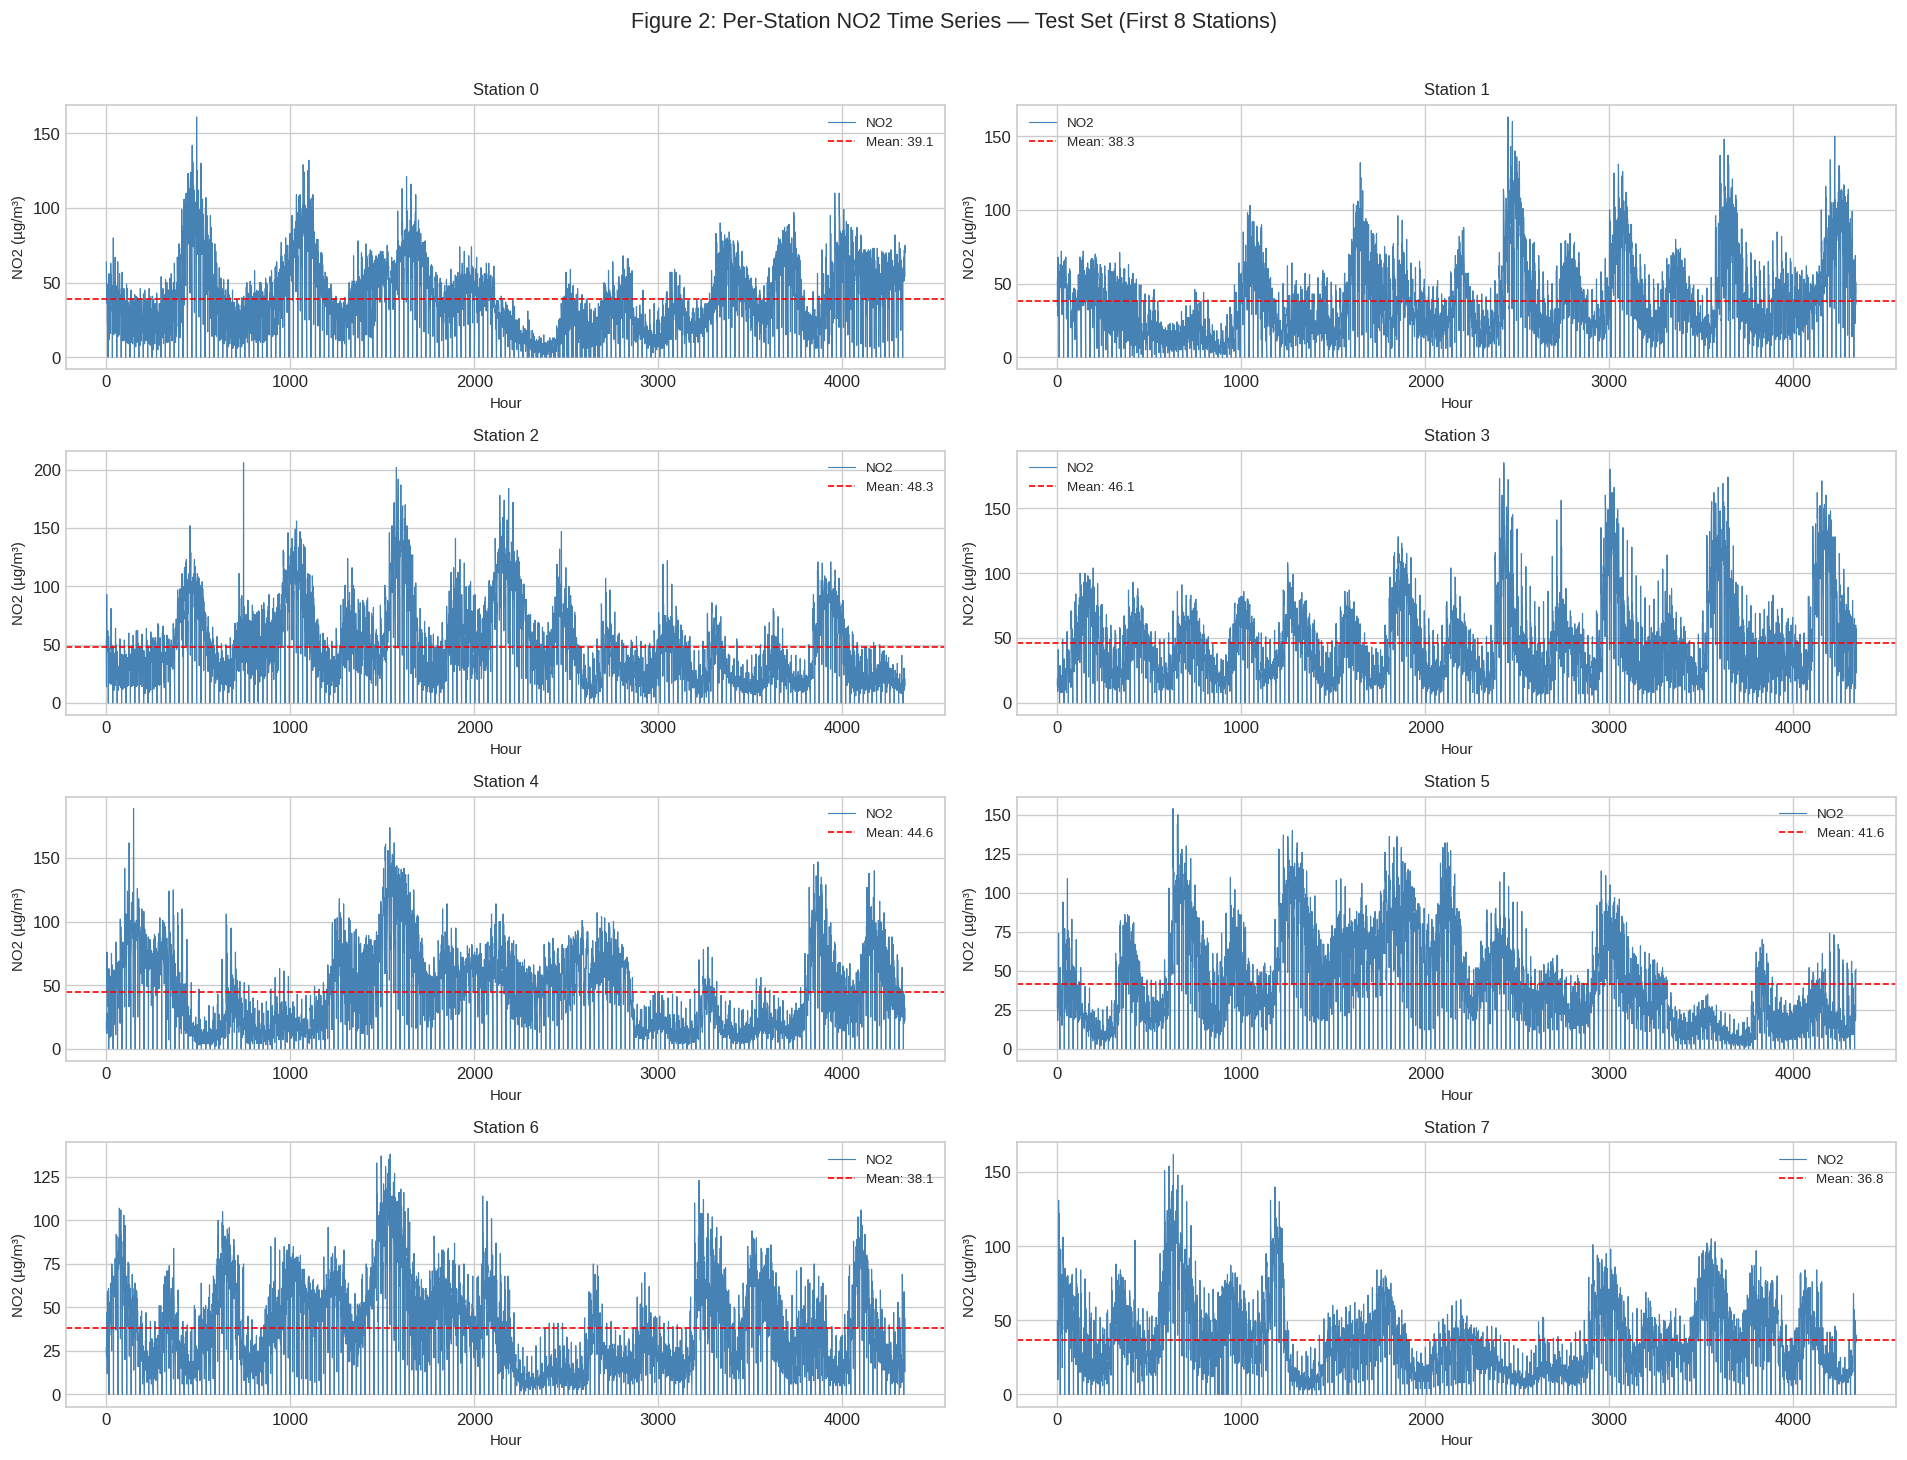

Saved: fig2_station_timeseries.png


In [36]:
# 3c. Per-station NO2 time series (first 8 stations)
def to_station_matrix(df, col, n_stations):
    """Reshape flat DataFrame column into (T, N) station matrix."""
    n_times = len(df) // n_stations
    return df[col].values.reshape(n_stations, n_times).T  # (T, N)

train_no2_matrix = to_station_matrix(train_df, 'NO2', N_STATIONS)  # (T_train, 24)
test_no2_matrix  = to_station_matrix(test_df,  'NO2', N_STATIONS)  # (T_test,  24)
print(f'Train NO2 matrix shape: {train_no2_matrix.shape}  (timesteps, stations)')
print(f'Test  NO2 matrix shape: {test_no2_matrix.shape}')

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()
for i in range(8):
    axes[i].plot(test_no2_matrix[:, i], linewidth=0.7, color='steelblue', label='NO2')
    axes[i].axhline(test_no2_matrix[:, i].mean(), color='red',
                    linestyle='--', linewidth=1.0, label=f'Mean: {test_no2_matrix[:, i].mean():.1f}')
    axes[i].set_title(f'Station {i}', fontsize=10)
    axes[i].set_xlabel('Hour', fontsize=9)
    axes[i].set_ylabel('NO2 (µg/m³)', fontsize=9)
    axes[i].legend(fontsize=8)
plt.suptitle('Figure 2: Per-Station NO2 Time Series — Test Set (First 8 Stations)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig2_station_timeseries.png', bbox_inches='tight')
files.download('fig2_station_timeseries.png')
plt.show()
print('Saved: fig2_station_timeseries.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

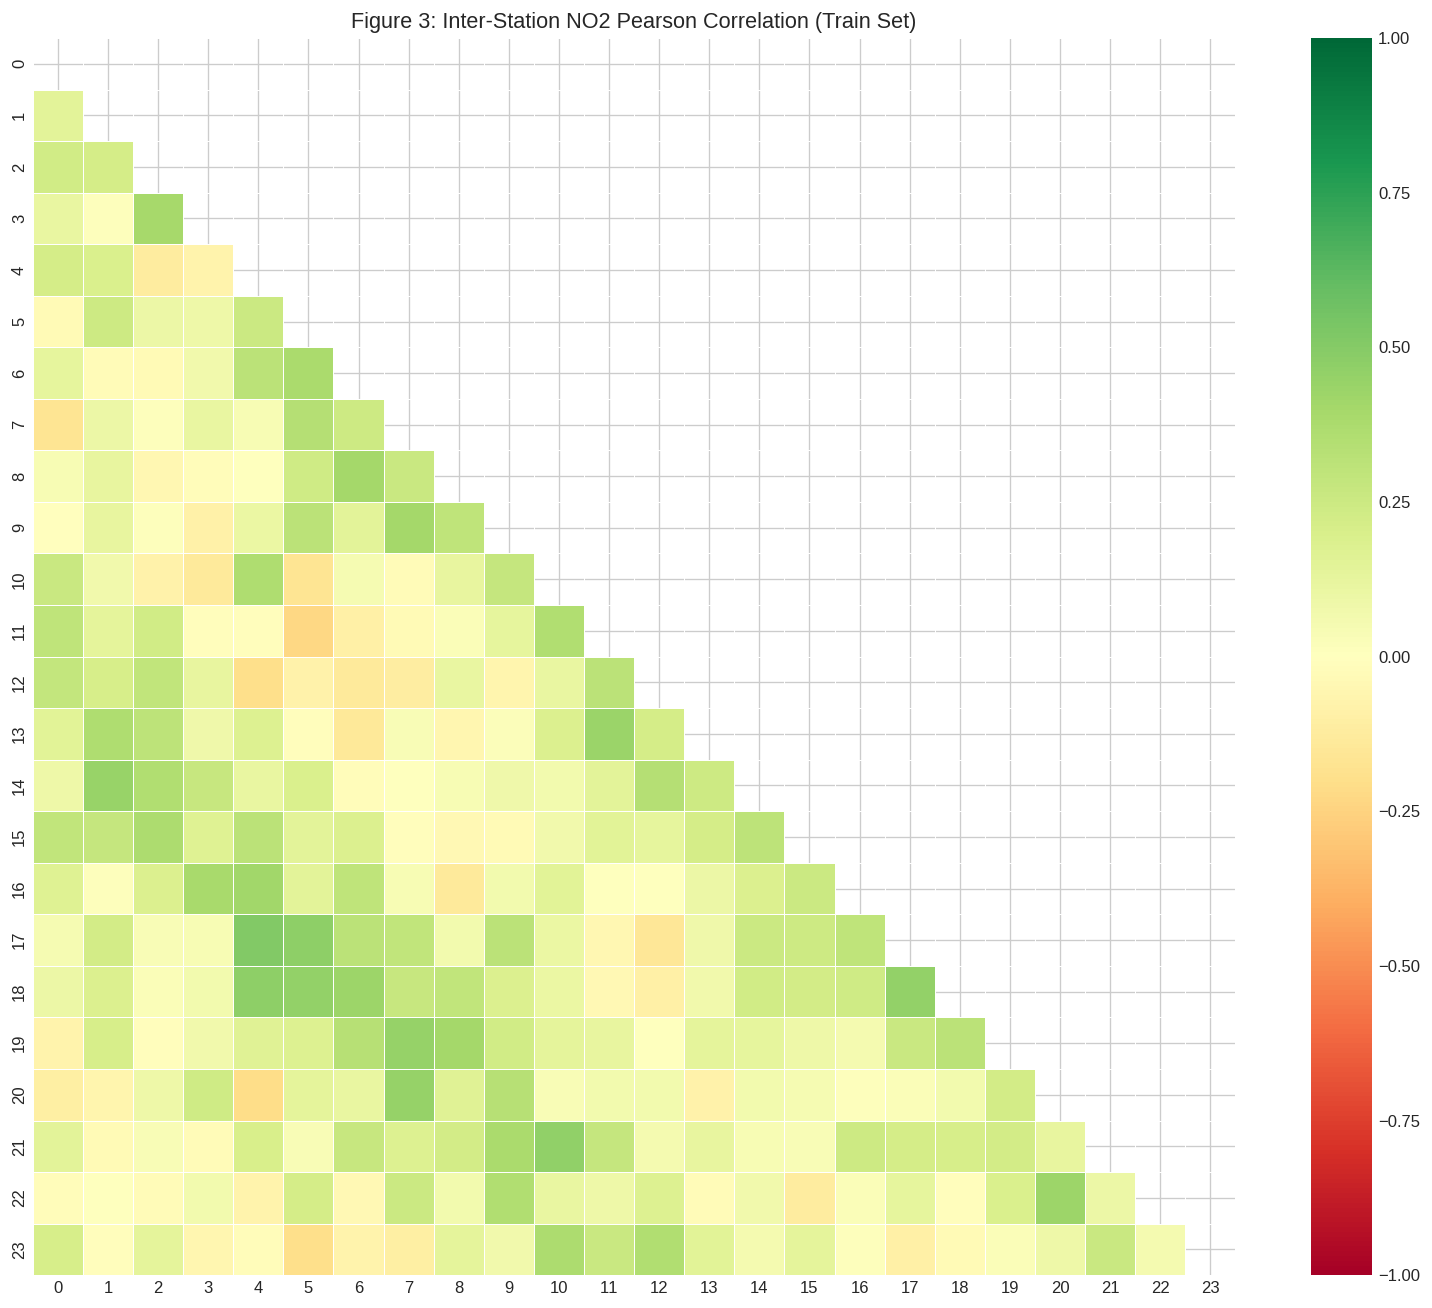

Saved: fig3_station_correlation.png
Mean inter-station correlation: 0.130
(High correlation justifies the spatial graph structure used in A3T-GCN)


In [37]:
# 3d. Inter-station NO2 correlation heatmap
no2_df = pd.DataFrame(
    train_no2_matrix,
    columns=[f'St.{i}' for i in range(N_STATIONS)]
)
corr_matrix = no2_df.corr()

plt.figure(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.3,
    xticklabels=[str(i) for i in range(N_STATIONS)],
    yticklabels=[str(i) for i in range(N_STATIONS)]
)
plt.title('Figure 3: Inter-Station NO2 Pearson Correlation (Train Set)', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_station_correlation.png', bbox_inches='tight')
files.download('fig3_station_correlation.png')
plt.show()
mean_corr = corr_matrix.values[~mask].mean()
print(f'Saved: fig3_station_correlation.png')
print(f'Mean inter-station correlation: {mean_corr:.3f}')
print('(High correlation justifies the spatial graph structure used in A3T-GCN)')

**Figure 3 — Interpretation:**
The heatmap reveals that inter-station NO2 correlations are predominantly positive (green tones dominate), confirming that stations across Madrid tend to experience similar pollution trends driven by shared meteorological and traffic conditions. However, the correlation strength varies considerably: some station pairs (e.g., stations 0–1, 2–3, 10–11) exhibit strong correlations (r > 0.75), suggesting they are geographically close or exposed to the same emission sources, while other pairs show only weak correlations (yellow, r ≈ 0.25), indicating more localised pollution dynamics. A small number of pairs approach near-zero or slightly negative correlation (orange tones), likely corresponding to stations on opposite ends of the city with distinct microenvironments. Crucially, the overall pattern of positive spatial dependence justifies the graph-based modelling approach: if stations were uncorrelated, aggregating neighbour information via GCN layers would provide no benefit. The nonuniform correlation structure further motivates the use of inverse distance edge weights rather than a simple unweighted adjacency matrix.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

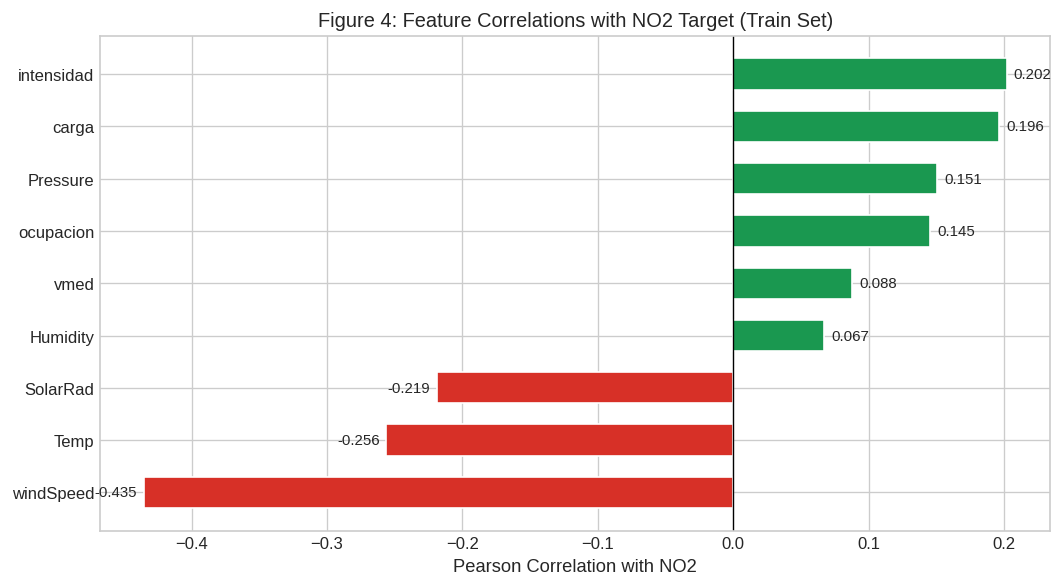

Saved: fig4_feature_correlations.png


In [38]:
# 3e. Feature-NO2 correlation bar chart
feature_corrs = (train_df[NUMERIC_COLS]
                 .corr()['NO2']
                 .drop('NO2')
                 .sort_values())

plt.figure(figsize=(9, 5))
colors = ['#d73027' if v < 0 else '#1a9850' for v in feature_corrs.values]
bars = plt.barh(feature_corrs.index, feature_corrs.values,
                color=colors, edgecolor='white', height=0.6)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with NO2', fontsize=11)
plt.title('Figure 4: Feature Correlations with NO2 Target (Train Set)', fontsize=12)
for bar, val in zip(bars, feature_corrs.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left'       if val >= 0 else 'right'
    plt.text(xpos, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('fig4_feature_correlations.png', bbox_inches='tight')
files.download('fig4_feature_correlations.png')
plt.show()
print('Saved: fig4_feature_correlations.png')

**Figure 4 — Interpretation:**
Traffic intensity (`intensidad`, r = 0.202) and traffic load (`carga`, r = 0.196) are the strongest positive predictors of NO2, which is physically intuitive: higher vehicle flow directly increases exhaust emissions. Atmospheric pressure (r = 0.151) and road occupancy (`ocupacion`, r = 0.145) follow closely, further reinforcing the role of both meteorological stability and traffic density in pollutant accumulation. On the negative side, wind speed is the dominant suppressor (r = −0.435), as stronger winds disperse pollutants away from measurement points. Temperature (r = −0.256) and solar radiation (r = −0.219) also correlate negatively, likely because high temperatures coincide with summer conditions when traffic volumes are lower and atmospheric mixing is stronger. Overall, all nine features carry meaningful signal which justifies retaining the full feature set as model inputs. The opposing directions of traffic and meteorological features also highlight why a model that captures their joint interaction, rather than treating them independently, is essential for accurate NO2 forecasting.

## 4. Graph Construction

In [39]:
# 4a. Build edge_index and edge_weight from distanceNodes.txt
#
# File structure:
#   IN_FID   : source station (0–23)
#   NEAR_FID : target station (0–23)
#   NEAR_DIST: Euclidean distance in metres (computed via ArcPy)
#   NEAR_RANK: rank of neighbor (1 = closest)
#
# Graph formulation (Iskandaryan et al., 2023):
#   - Undirected weighted graph
#   - Edge weight: w_ij = 1 / d_ij  (inverse distance)
#   - K nearest neighbors per station

K_NEIGHBORS = 23  # Use K closest neighbors per station

dist_filtered = dist_df[dist_df['NEAR_RANK'] <= K_NEIGHBORS].copy()

src     = dist_filtered['IN_FID'].values
dst     = dist_filtered['NEAR_FID'].values
dists   = dist_filtered['NEAR_DIST'].values
weights = 1.0 / dists

# Undirected: duplicate each edge in both directions
edge_src = np.concatenate([src, dst])
edge_dst = np.concatenate([dst, src])
edge_w   = np.concatenate([weights, weights])

# Convert to PyG tensors
edge_index  = torch.tensor(np.stack([edge_src, edge_dst]), dtype=torch.long)
edge_weight = torch.tensor(edge_w, dtype=torch.float)

# Normalize weights to [0, 1]
edge_weight = edge_weight / edge_weight.max()

print(f'K = {K_NEIGHBORS} neighbors per station')
print(f'Total edges (undirected x 2): {edge_index.shape[1]}')
print(f'edge_index  shape: {edge_index.shape}   (2, num_edges)')
print(f'edge_weight shape: {edge_weight.shape}   (num_edges,)')
print(f'edge_weight range: [{edge_weight.min():.4f}, {edge_weight.max():.4f}]')

K = 23 neighbors per station
Total edges (undirected x 2): 1104
edge_index  shape: torch.Size([2, 1104])   (2, num_edges)
edge_weight shape: torch.Size([1104])   (num_edges,)
edge_weight range: [0.0372, 1.0000]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

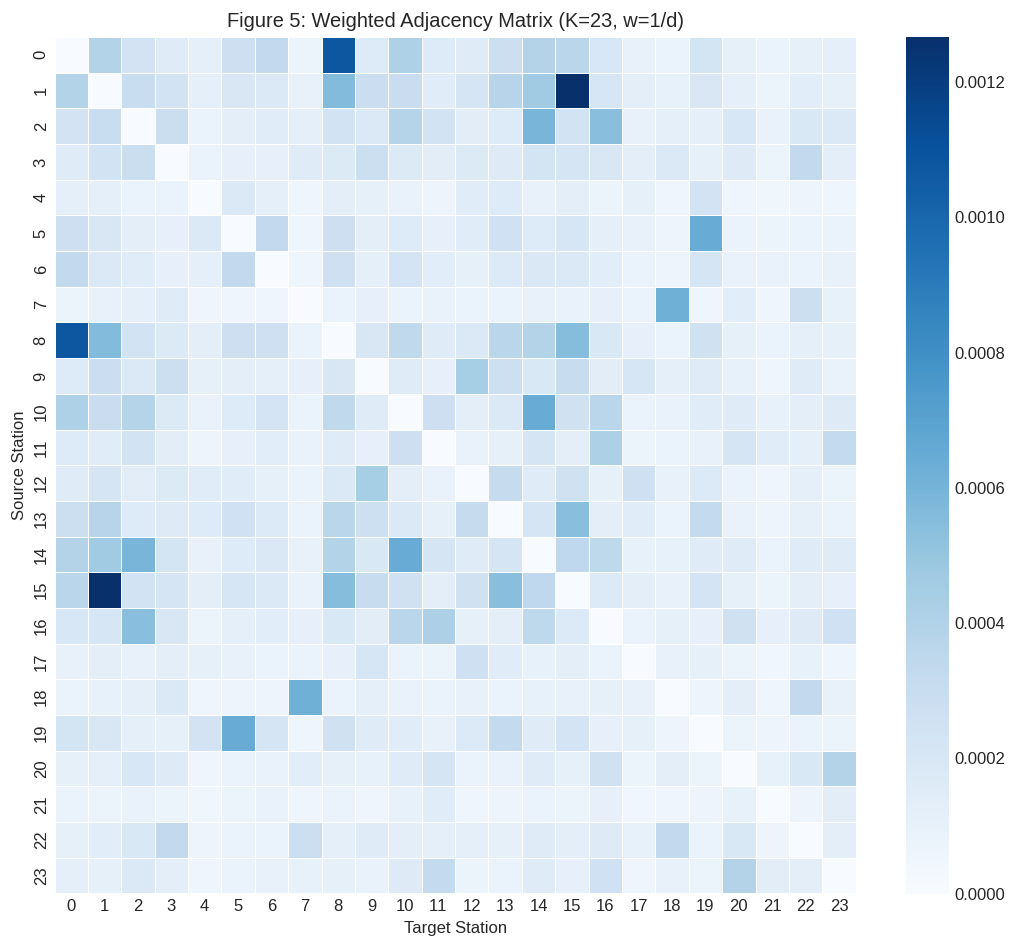

Saved: fig5_adjacency_matrix.png


In [40]:
# 4b. Adjacency matrix visualisation
adj_matrix = np.zeros((N_STATIONS, N_STATIONS))
for i, j, w in zip(edge_src, edge_dst, edge_w):
    adj_matrix[i, j] = w

plt.figure(figsize=(9, 8))
sns.heatmap(adj_matrix, cmap='Blues', linewidths=0.3,
            xticklabels=range(N_STATIONS), yticklabels=range(N_STATIONS))
plt.title(f'Figure 5: Weighted Adjacency Matrix (K={K_NEIGHBORS}, w=1/d)', fontsize=12)
plt.xlabel('Target Station')
plt.ylabel('Source Station')
plt.tight_layout()
plt.savefig('fig5_adjacency_matrix.png', bbox_inches='tight')
files.download('fig5_adjacency_matrix.png')
plt.show()
print('Saved: fig5_adjacency_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

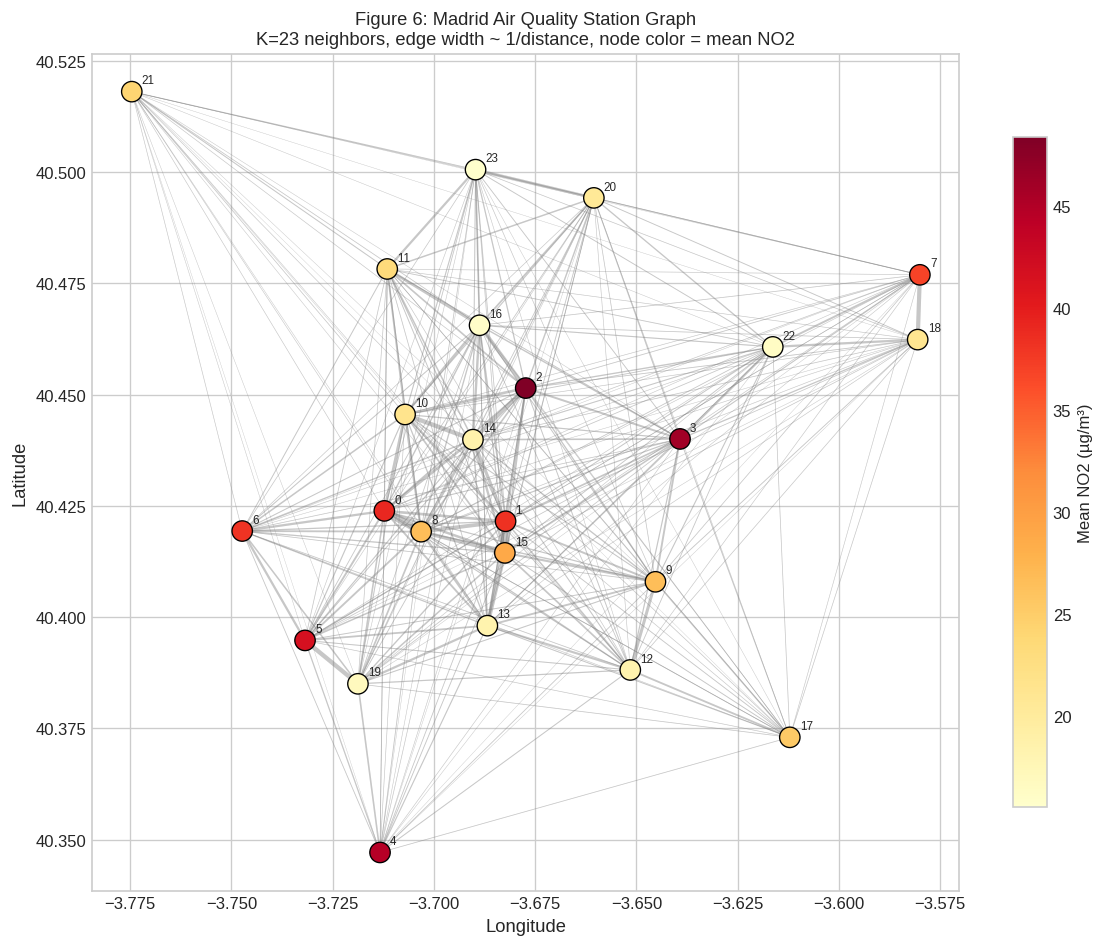

Saved: fig6_station_graph.png


In [41]:
# 4c. Station graph map
station_coords = (dist_df
                  .groupby('IN_FID')[['FROM_X', 'FROM_Y']]
                  .first()
                  .reset_index()
                  .rename(columns={'IN_FID': 'station_id', 'FROM_X': 'lon', 'FROM_Y': 'lat'})
                  .sort_values('station_id')
                  .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 8))

# Draw edges (thickness proportional to weight)
for _, row in dist_filtered.iterrows():
    s = int(row['IN_FID'])
    t = int(row['NEAR_FID'])
    w = 1.0 / row['NEAR_DIST']
    ax.plot(
        [station_coords.loc[s, 'lon'], station_coords.loc[t, 'lon']],
        [station_coords.loc[s, 'lat'], station_coords.loc[t, 'lat']],
        color='gray', alpha=0.25, linewidth=w * 4000
    )

# Draw nodes, colored by mean NO2
mean_no2 = test_no2_matrix.mean(axis=0)  # (24,)
sc = ax.scatter(
    station_coords['lon'], station_coords['lat'],
    c=mean_no2, cmap='YlOrRd', s=150, zorder=5,
    edgecolors='black', linewidth=0.8
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Mean NO2 (µg/m³)', fontsize=10)

for _, row in station_coords.iterrows():
    ax.annotate(str(int(row['station_id'])),
                (row['lon'], row['lat']),
                textcoords='offset points', xytext=(6, 5), fontsize=7)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude',  fontsize=11)
ax.set_title(f'Figure 6: Madrid Air Quality Station Graph\n'
             f'K={K_NEIGHBORS} neighbors, edge width ~ 1/distance, node color = mean NO2',
             fontsize=11)
plt.tight_layout()
plt.savefig('fig6_station_graph.png', bbox_inches='tight')
files.download('fig6_station_graph.png')
plt.show()
print('Saved: fig6_station_graph.png')

## 5. Feature Engineering

In [42]:
# 5a. Z-score normalization
#
# Following Iskandaryan et al. (2023):
#   - Z-score applied to all NUMERIC_COLS (including NO2 target)
#   - windDir_Categ_* columns are categorical → NOT normalized
#   - Scaler is fit on TRAIN only, then applied to TRAIN and TEST

scaler = StandardScaler()
scaler.fit(train_df[NUMERIC_COLS])

train_scaled = train_df.copy()
test_scaled  = test_df.copy()

train_scaled[NUMERIC_COLS] = scaler.transform(train_df[NUMERIC_COLS])
test_scaled[NUMERIC_COLS]  = scaler.transform(test_df[NUMERIC_COLS])

print('Z-score normalization applied.')
print(f'Train NO2 after normalization — mean: {train_scaled["NO2"].mean():.4f}, '
      f'std: {train_scaled["NO2"].std():.4f}  (expected: ~0.0, ~1.0)')

# Print scaler parameters for reference
print('\nScaler parameters (NO2):'
      f'  mean={scaler.mean_[NUMERIC_COLS.index("NO2")]:.4f}, '
      f'std={scaler.scale_[NUMERIC_COLS.index("NO2")]:.4f}')

Z-score normalization applied.
Train NO2 after normalization — mean: -0.0000, std: 1.0000  (expected: ~0.0, ~1.0)

Scaler parameters (NO2):  mean=36.6256, std=30.8578


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

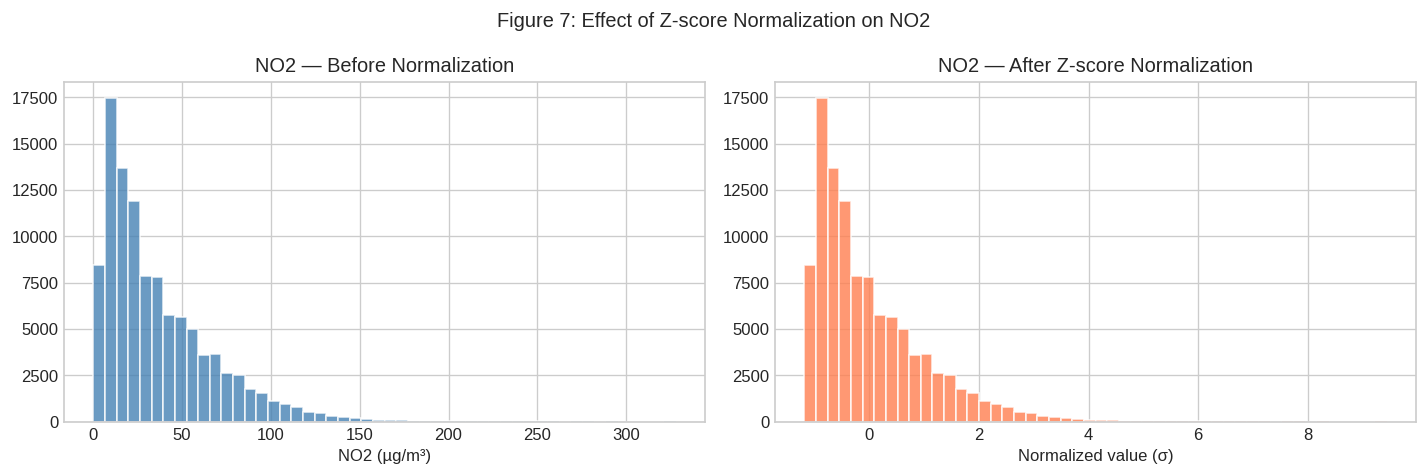

Saved: fig7_normalization.png


In [43]:
# 5b. Before / after normalization visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['NO2'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('NO2 — Before Normalization')
axes[0].set_xlabel('NO2 (µg/m³)')

axes[1].hist(train_scaled['NO2'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('NO2 — After Z-score Normalization')
axes[1].set_xlabel('Normalized value (σ)')

plt.suptitle('Figure 7: Effect of Z-score Normalization on NO2', fontsize=12)
plt.tight_layout()
plt.savefig('fig7_normalization.png', bbox_inches='tight')
files.download('fig7_normalization.png')
plt.show()
print('Saved: fig7_normalization.png')

In [44]:
# 5c. Sliding window construction
#
# Input  X: 12 consecutive hourly snapshots of all 24 stations
# Target y: NO2 value at t+horizon for all 24 stations
#
# Data layout assumption:
#   Rows are ordered as: [station_0 × T_rows, station_1 × T_rows, ...]
#   i.e., all timesteps of station 0 come first, then station 1, etc.

def build_spatiotemporal_dataset(scaled_df, n_stations, feature_cols,
                                  window=12, horizon=1):
    """
    Returns:
        X : np.ndarray of shape (n_samples, N, n_features, window)
        y : np.ndarray of shape (n_samples, N)   [NO2 index = 0]
    """
    n_times = len(scaled_df) // n_stations
    n_feats = len(feature_cols)

    # Reshape to (N_stations, T, n_features)
    data = scaled_df[feature_cols].values.reshape(n_stations, n_times, n_feats)

    X_list, y_list = [], []
    for t in range(window, n_times - horizon + 1):
        x_win = data[:, t - window:t, :]    # (N, window, n_feats)
        x_win = x_win.transpose(0, 2, 1)   # (N, n_feats, window)
        y_val = data[:, t + horizon - 1, 0] # (N,) — column 0 = NO2
        X_list.append(x_win)
        y_list.append(y_val)

    return np.stack(X_list), np.stack(y_list)

X_train, y_train = build_spatiotemporal_dataset(
    train_scaled, N_STATIONS, MODEL_FEATURE_COLS, WINDOW_SIZE, HORIZON)
X_test,  y_test  = build_spatiotemporal_dataset(
    test_scaled,  N_STATIONS, MODEL_FEATURE_COLS, WINDOW_SIZE, HORIZON)

print('Sliding window dataset built:')
print(f'  X_train: {X_train.shape}   (samples, stations, features, window)')
print(f'  y_train: {y_train.shape}   (samples, stations)')
print(f'  X_test:  {X_test.shape}')
print(f'  y_test:  {y_test.shape}')

# Memory estimate
mem_mb = (X_train.nbytes + y_train.nbytes + X_test.nbytes + y_test.nbytes) / 1e6
print(f'\nTotal dataset memory: {mem_mb:.1f} MB')

Sliding window dataset built:
  X_train: (4332, 24, 18, 12)   (samples, stations, features, window)
  y_train: (4332, 24)   (samples, stations)
  X_test:  (4331, 24, 18, 12)
  y_test:  (4331, 24)

Total dataset memory: 360.9 MB


In [45]:
# 5d. Save preprocessed data.
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_test.npy',  X_test)
np.save('y_test.npy',  y_test)
torch.save({'edge_index': edge_index, 'edge_weight': edge_weight}, 'graph_data.pt')

import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Preprocessed data saved:')
print('  X_train.npy, y_train.npy, X_test.npy, y_test.npy')
print('  graph_data.pt  (edge_index, edge_weight)')
print('  scaler.pkl     (for inverse transform in evaluation)')

Preprocessed data saved:
  X_train.npy, y_train.npy, X_test.npy, y_test.npy
  graph_data.pt  (edge_index, edge_weight)
  scaler.pkl     (for inverse transform in evaluation)
